# 04 · 메모리와 상태: 지속되는 척추

**구성요소:** 메모리 / 상태 — 루프의 지속되는 척추.

**핵심 아이디어**

> "모델에게는 턴과 세션을 가로지르는 장기 기억이 없다. 루프는 지속되는 무언가에 쓰고, 그것에서 읽어야 한다."

> 좋은 상태는 세 질문에 답한다 — **지금 무엇을 하고 있는가, 지난번에 무엇을 시도했는가, 무엇이 사람을 기다리고 있는가.**

**문제 설정** — 모델은 자기 바깥에 사는 사실을 알 수 없다. 팀의 관습, 어제 내린 결정, 실측으로 남은 이력이 그렇다. 루프 엔지니어링(loop engineering)의 지엽적인 원리와 **이 프로젝트 자체**에 관해 물으면 폐쇄형(closed-book) 모델은 답을 지어낸다. 그 지식을 지속되는 저장소에 담아 두고 매 실행마다 해당 대목을 검색해 온다면(검색 증강, retrieval-augmented) **같은 모델이 정확히 답한다.**

**측정 대상** — 사실 질문에 대한 정답률을, 두 조건에서 잰다.

- **폐쇄형** — 질문만 준다. 모델은 가중치 안에 있는 것으로만 답해야 한다.
- **검색 증강** — 루프 엔지니어링 원리와 이 프로젝트의 실측 결과를 담은 메모리에서 관련 대목을 찾아 프롬프트에 붙여 준다.

메모리가 지속되는 외부 상태이고, 검색은 루프가 그것을 **읽는 경로**다. 그다음 **상태 부패(state rot)** 를 일부러 재현한다. 메모리를 오염시키고, 관련성 임계값으로 대응한다.

**정직한 예고** — 상태 부패 실험은 이 실행에서 **아무 손상도 만들지 못했다.** 원저자는 그 귀무 결과를 지우지 않았고, 한국어판도 그대로 옮긴다. 왜 손상이 없었는지는 뒤에서 다룬다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

============================================== Setup ===============================================

-------------------------------------------- 엔진 health ---------------------------------------------
{
  "provider": "openai",
  "model": "gpt-5.6-luna",
  "base_url": "(\uacf5\uc2dd \uc5d4\ub4dc\ud3ec\uc778\ud2b8)",
  "reply": "ready",
  "deterministic": true,
  "cost_usd": "$0.0000",
  "resolved_by": "localho

*질의를 임베딩하고, 지속되는 메모리에서 검색하고, 프롬프트를 증강해 답한다*

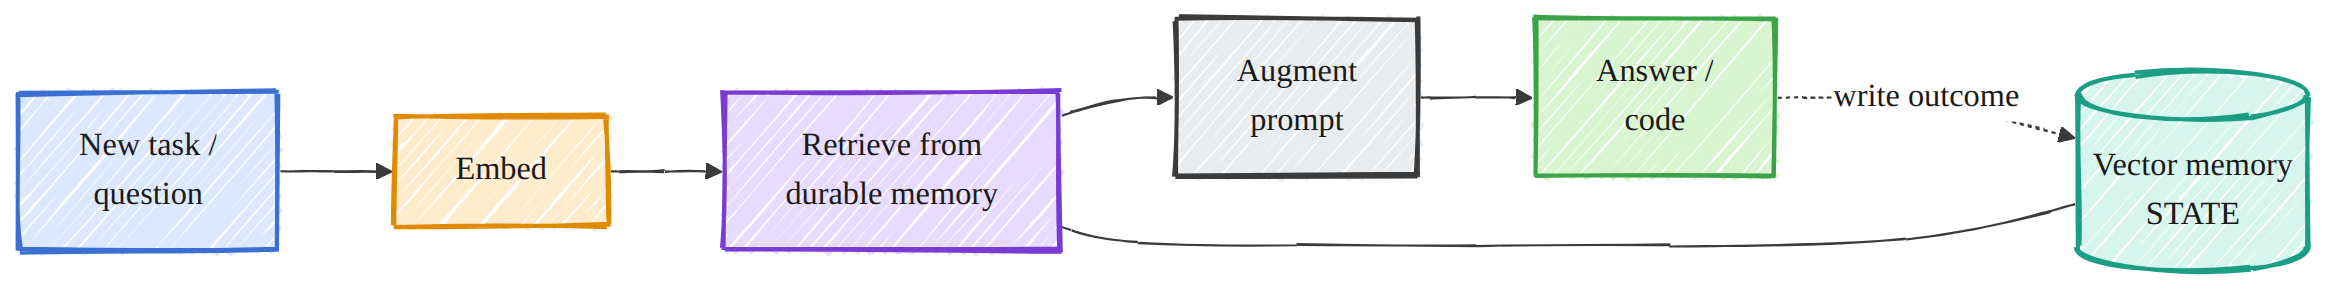

  메모리 문단 수:                  22
  질문 수:                      14

---------------------------------------- 임베딩 백엔드 (자동 판별 결과) ----------------------------------------
{
  "backend": "openai",
  "model": "text-embedding-3-small",
  "device": "(\uc6d0\uaca9)",
  "query_instruction": false,
  "docs": 22,
  "cached_vectors": 22,
  "resolved_by": "CUDA \ubbf8\uac00\uc6a9 \u2192 API \uc784\ubca0\ub529 \u00b7 \uae30\ubcf8\uac12 (\uce90\uc2dc)"
}
  - 문서를 임베딩해 메모리에 올렸다. 이것이 지속되는 저장소다.


  - Embedded the documentation into GPU memory with BGE; this is the durable store.


In [1]:
import os
import sys

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, plotting, runlog, runtime
from common.llm import LLM
from common.memory import EmbeddingMemory

# 실행 환경 자동 판별 (로컬 vLLM 우선, 없으면 OpenAI API)
rt = runtime.bootstrap()

llm = LLM()
show.head("Setup")
show.show_dict(llm.health(), "엔진 health")
show.diagram("memory_rag", "질의를 임베딩하고, 지속되는 메모리에서 검색하고, 프롬프트를 증강해 답한다")

# ── 지속되는 메모리 ───────────────────────────────────────────────
# 두 종류가 일부러 섞여 있다. 앞쪽은 일반적인 루프 엔지니어링 원리이고,
# 주석 아래쪽은 이 프로젝트가 직접 측정한 사실이다. 후자는 이 메모리
# 없이는 알 방법이 없고, 바로 그 점이 이 노트북의 논지다.
PASSAGES = [
    "A verifier sub-agent has a default stance of REJECT until proven otherwise, and does not trust the implementer's claim that tests passed; it runs the tests itself.",
    "A common guardrail caps automated fix attempts at three, after which the loop escalates to a human with full context.",
    "Worktrees give each agent its own working directory that shares git history but not the working tree, preventing parallel collisions.",
    "A common loop state file has three sections: High Priority, Watch List, and Recent Noise, plus a Last run timestamp.",
    "A typical path denylist includes .env files, secrets, auth, payments, billing, migrations, and k8s production directories.",
    "The cost model's realistic mix at readiness level L1 with early-exit is about 90 percent no-op and 10 percent full triage.",
    "When loops conflict, a sensible priority order is CI Sweeper first, then PR Babysitter, then Dependency Sweeper, then Post-Merge Cleanup, then Daily Triage.",
    "Intent debt is paid down by skills: conventions, build steps, and domain knowledge written once and read on every run.",
    "Verifier theater is when a verifier approves work but the tests actually fail; the fix is to force the verifier to run the test and lint commands.",
    "The building blocks of a loop are scheduling, worktrees, skills, connectors, sub-agents, and durable state.",
    "Readiness levels are L1 report-only, L2 assisted fixes with a verifier, and L3 unattended with a denylist, budget, and human gates.",
    "State rot is when the state file references merged work or closed tickets; the fix is to prune resolved items every run.",
    "MCP, the Model Context Protocol, is the common substrate for connectors so a connector written for one tool often works in another.",
    "Connectors should follow least privilege: read and comment before write, and never a production database write from a loop.",
    "The run log records one JSON entry per run with run_id, pattern, duration, items_found, actions_taken, escalations, tokens_estimate, and outcome.",
    # 여기서부터는 이 프로젝트가 직접 측정한 사실 (메모리 없이는 알 수 없다)
    "This notebook series serves the Qwen2.5-Coder-32B-Instruct model, AWQ quantized, on an A100 GPU via vLLM.",
    "In this series the run-until-done loop lifted MBPP+ pass-rate by 8.3 points using execution feedback.",
    "In this series a test-running verifier cut wrong-code false-accept from 100 percent to 31 percent.",
    "In this series git worktrees preserved 100 percent of parallel work, versus 17 percent for a shared working tree.",
    "The embedding model used throughout this series is BAAI bge-large-en-v1.5.",
    "In this series the schema-as-skill took text-to-SQL from 0 percent executable to 95 percent.",
    "In this series the code-execution tool lifted data-analysis accuracy from 10 percent to 83 percent.",
]

# ⚠️ 함정: 코퍼스와 질문은 영어 그대로 둔다. 임베딩 모델(bge-large-en / OpenAI)이
#    영어 기준으로 학습됐고, 코퍼스만 번역하면 질의-문서 벡터 공간이 어긋나
#    검색 점수가 무너진다. 측정 대상은 번역 품질이 아니라 검색 유무다.
QA = [
    ("What is a verifier sub-agent's default stance?", ["reject"]),
    ("What is the common cap on automated fix attempts?", ["three", "3"]),
    ("Which model does this notebook series serve?", ["qwen", "32b", "coder"]),
    ("How many points did the run-until-done loop lift MBPP+ in this series?", ["8.3", "8 point"]),
    ("To what value did the test-running verifier cut wrong-code false-accept in this series?", ["31"]),
    ("Name one path on a typical denylist.", ["auth", "payments", "billing", "secrets", "migrations", ".env", "k8s"]),
    ("What embedding model does this series use?", ["bge"]),
    ("What are the three sections of a common loop state file?", ["high priority", "watch list", "recent noise"]),
    ("What is state rot?", ["merged", "closed", "stale", "prune"]),
    ("What is the realistic no-op fraction for L1 with early-exit?", ["90", "ninety"]),
    ("What protocol is the common substrate for connectors?", ["mcp", "model context protocol"]),
    ("To what accuracy did the code-execution tool lift data analysis in this series?", ["83"]),
    ("What fields does the run log record per run?", ["run_id", "tokens", "outcome", "escalations"]),
    ("What is the connector least-privilege rule?", ["read", "comment", "before write", "least privilege"]),
]

show.kv("메모리 문단 수", len(PASSAGES))
show.kv("질문 수", len(QA))

# 한국어판 수정: 원본은 임베딩 백엔드와 장치를 인자로 못박았지만, 여기서는 비운다.
# common/runtime.py 의 resolve_embed() 가 실행 환경을 보고 스스로 정한다.
#   · CUDA 가 보이면        → local + BAAI/bge-large-en-v1.5 + device="cuda"
#   · GPU 가 없으면         → 같은 계열의 경량 모델 bge-small 로 자동 강등
#   · sentence-transformers 가 없고 API 키만 있으면 → OpenAI 임베딩
# 인자를 비워야 GPU 서버·노트북·CPU 전용 환경에서 같은 셀이 그대로 돌아간다.
# 더 중요한 것은 백엔드에 따라 '쿼리 지시문' 규약이 달라진다는 점이다(아래 이론 블록).
mem = EmbeddingMemory()
mem.add(PASSAGES)
mem.index()          # 여기서 22개 문단이 한 번에 임베딩된다. 비용이 드는 유일한 지점이다.

show.show_dict(mem.describe(), "임베딩 백엔드 (자동 판별 결과)")
show.bullet("문서를 임베딩해 메모리에 올렸다. 이것이 지속되는 저장소다.")

### 두 종류의 기억: 파라메트릭 기억과 외부 기억

셋업이 지속되는 저장소를 만든다. 짧은 문단 **22개**가 임베딩됐고, 그것을 찔러 볼 사실 질문 **14개**가 준비됐다. 숫자를 하나라도 재기 전에, 지금 무대에 올라와 있는 두 종류의 기억을 갈라 두는 편이 좋다.

- **파라메트릭 기억(parametric memory)** — 학습이 가중치에 구워 넣은 것. 넓은 상식, 흔한 관용구, 잘 알려진 API 의 생김새.
- **외부 기억(external memory)** — 학습이 끝난 뒤에 결정됐거나, 애초에 한 프로젝트 안에만 사는 것. 팀의 관습, 지난 실행의 결과, 이 프로젝트가 직접 측정한 수치.

**모델은 첫 번째 종류를 공짜로 지고 다니고, 두 번째 종류는 아예 지고 다닐 수 없다.**

문단 목록이 일부러 섞여 있는 이유가 여기 있다. 어떤 항목은 일반 원리다 — 검증기의 기본 입장은 거절이다, 수정 루프는 시도 3회에서 멈춘다. 강한 모델이라면 재구성해 볼 여지가 있다. 나머지는 **이 프로젝트가 실측한 사실**이다. 서빙 중인 모델명, +8.3점의 개선폭, 오수용 수치, text-to-SQL 결과. **이것들은 차갑게는 알 수 없다.** 이번 실행이 만들어 낸 숫자가 사전학습 데이터에 들어 있을 방법이 없기 때문이다.

검색은 루프가 두 번째 종류를 읽어 오는 메커니즘이다. 질의를 임베딩하고, 코사인 유사도로 가장 가까운 문단을 찾아 접지(grounding)로 프롬프트에 붙인다. **결과가 갈리는 선이 저 이음매와 겹치는지를 지켜보라.**


In [2]:
# ── 채점기와 질의 함수 ────────────────────────────────────────────
# 이 노트북의 처치 변수는 딱 하나, ask() 에 context 가 들어가는가 여부다.
# 모델·온도·최대 토큰은 두 조건에서 완전히 동일하다.

def answers_match(resp, accept):
    # ⚠️ 함정: 부분 문자열 포함 검사는 관대한 채점기다. 정답 조각이 문장 어딘가에
    #    있기만 하면 통과하므로, 모델이 얼버무리며 답을 흘려도 정답 처리될 수 있다.
    #    여기서는 폐쇄형이 '추측조차 못 한다' 는 것을 보이는 게 목적이라 관대한
    #    쪽이 오히려 보수적이다. 관대한 채점기로도 7퍼센트라는 뜻이기 때문이다.
    r = (resp or "").lower()
    return any(a.lower() in r for a in accept)


def ask(question, context=None):
    if context:
        # "이 컨텍스트만 써서" 라는 제약이 중요하다. 이것이 없으면 모델이 검색된
        # 문단과 자기 추측을 섞어 버려, 개선이 검색 덕분인지 알 수 없게 된다.
        prompt = f"Use only this context to answer concisely.\n\nContext:\n{context}\n\nQuestion: {question}\nAnswer:"
    else:
        prompt = f"Answer this question about the loop-engineering project concisely.\n\nQuestion: {question}\nAnswer:"
    # temperature=0.0 — 탐욕적 디코딩. 두 조건의 차이가 샘플링 운이 아니어야 한다.
    return llm.complete(prompt, temperature=0.0, max_tokens=64, label="qa").text.strip()

## 한 질문으로 보는 추적


### 상태를 읽는 경로로서의 검색

대규모로 돌리기 전에, 질문 하나를 끝에서 끝까지 따라가 메커니즘을 구체적으로 만든다. 고른 질문은 **이 시리즈가 어떤 모델을 서빙하는가**다. 이것은 순수한 외부 기억 사실이다. 답인 `Qwen2.5-Coder-32B-Instruct`(AWQ 양자화, A100 위 vLLM)는 세상에 관한 사실이 아니라 **이 셋업의 속성**이다. 폐쇄형 모델은 가중치에서 꺼내 올 것이 없으므로 추측하는 수밖에 없다.

검색 증강 경로는 질문과 답 사이에 네 단계를 끼워 넣는다.

1. 질의를 **문단들과 같은 벡터 공간**으로 임베딩한다.
2. 모든 문단을 유사도로 채점한다.
3. 상위 1개를 가져온다.
4. **그 텍스트만을 컨텍스트로 삼아** 답한다.

예측은 깨끗한 뒤집힘이다. 폐쇄형은 빗나가고, 올바른 문단을 눈앞에 둔 같은 모델은 맞힌다.

여기서 조용한 진단 지표가 하나 더 있다. **매칭된 문단의 검색 점수**다. 건강한 매칭이라면 잡음 바닥보다 뚜렷하게 높은 곳에 있어야 한다. 그 값이 임베딩이 진짜 관련 사실을 찾은 것인지, 아니면 겉모습만 비슷한 이웃을 집어 온 것인지를 말해 준다.


In [3]:
# ── 단일 질문 추적: 같은 모델, 컨텍스트 유무만 다르게 ─────────────
q0, acc0 = QA[2]      # 서빙 모델을 묻는 질문. 추측이 원리적으로 불가능한 항목을 골랐다.
show.sub(q0)

cb = ask(q0)
show.text(cb, "폐쇄형 답변", max_chars=200)
show.kv("폐쇄형 정답 여부", answers_match(cb, acc0))

# k=1 — 추적에서는 상위 1개만 본다. 어느 문단 하나가 답을 실어 나르는지
# 눈으로 확인하는 것이 목적이다. 대규모 실행에서는 k=3 으로 올린다.
top = mem.retrieve(q0, k=1)[0]
show.text(top["doc"], f"검색된 메모리 (점수 {top['score']:.2f})", max_chars=250)

rag = ask(q0, context=top["doc"])
show.text(rag, "검색 증강 답변", max_chars=200)
show.kv("검색 증강 정답 여부", answers_match(rag, acc0))


--------------------------- Which model does this notebook series serve? ---------------------------

---------------------------------------------- 폐쇄형 답변 ----------------------------------------------

  폐쇄형 정답 여부:                 False

---------------------------------------- 검색된 메모리 (점수 0.52) -----------------------------------------
This notebook series serves the Qwen2.5-Coder-32B-Instruct model, AWQ quantized, on an A100 GPU via vLLM.

--------------------------------------------- 검색 증강 답변 ---------------------------------------------
Qwen2.5-Coder-32B-Instruct, AWQ quantized.
  검색 증강 정답 여부:               True



---------------------------------------- closed-book answer ----------------------------------------
The notebook series you're referring to seems to be part of the Loop-Engineering project, but without specific details about which notebook series you mean, it's challenging to pinpoint exactly which 
... [91 more chars truncated] ...
  closed-book correct:       False

---------------------------------- retrieved memory (score 0.67) -----------------------------------
This notebook series serves the Qwen2.5-Coder-32B-Instruct model, AWQ quantized, on an A100 GPU via vLLM.



------------------------------------ retrieval-augmented answer ------------------------------------
The notebook series serves the Qwen2.5-Coder-32B-Instruct model.
  RAG correct:               True


## 대규모: 폐쇄형 대 검색 증강


### 더 큰 프롬프트가 검색을 대신할 수 없는 이유

이 셀은 질문 14개 전부에 대해 대조를 돌린다. 각 질문을 폐쇄형으로 한 번, 상위 **3개** 문단을 컨텍스트로 붙여 한 번 더 묻는다.

검색이 옳은 도구인 이유는, 프롬프트를 길게 쓰거나 영리하게 쓰는 것으로는 안 되기 때문이다. **빠진 정보가 애초에 가중치 안에 없다.** 본 적 없는 측정값을 떠올리게 만드는 프롬프트란 존재하지 않는다. 상태를 저장하고 다시 꺼내 써야 하는 루프에 필요한 것은 **지속되는 저장소로 이어지는 읽기 경로**이지, 추측으로 채운 더 큰 컨텍스트 창이 아니다.

기대되는 그림은 이렇다. 폐쇄형 열은 바닥 근처, 살아남는 것이 있다면 재구성 가능한 일반 원리 몇 개뿐이다. 검색 열은 천장 근처다. **둘 사이의 격차가 루프에게 외부 기억을 준 것의 측정된 값어치다.**

그리고 정직하게 지켜볼 것이 하나 더 있다. **폐쇄형이 0 보다 조금 높게 나오는가.** 만약 그렇다면 그것은 모델이 짐작할 수 있는 일반 원리여야 하고, **결코 이 프로젝트 고유의 실측 사실이어서는 안 된다.**


In [4]:
# ── 대규모 실행: 질문 14개 × 두 조건 ──────────────────────────────
cb_ok = rag_ok = 0
for q, acc in QA:
    cb_resp = ask(q)                              # 조건 1: 컨텍스트 없음
    cb_hit = answers_match(cb_resp, acc)
    cb_ok += cb_hit

    # k=3 — 상위 1개만 쓰면 검색이 한 번만 빗나가도 답이 통째로 날아간다.
    # 3개는 재현율을 벌면서도 프롬프트가 관련 없는 문단으로 희석되지 않는 균형점이다.
    ctx = "\n".join(d["doc"] for d in mem.retrieve(q, k=3))
    rag_hit = answers_match(ask(q, context=ctx), acc)   # 조건 2: 검색된 컨텍스트
    rag_ok += rag_hit

    # ⚠️ 함정: 질문별 로그를 반드시 남긴다. 총계만 보면 폐쇄형이 맞힌 그 1개가
    #    '짐작 가능한 일반 원리' 인지 '실측 사실' 인지 구분할 수 없고,
    #    그 구분이 이 노트북의 핵심 주장 전체를 좌우한다.
    print(f"  closed-book={'OK ' if cb_hit else '.. '} rag={'OK ' if rag_hit else '.. '} {q[:55]}")

n = len(QA)
cb_acc, rag_acc = cb_ok / n, rag_ok / n
show.head("결과")
show.metric("폐쇄형 정답률", cb_acc)
show.metric("검색 증강 정답률", rag_acc)

  closed-book=..  rag=OK  What is a verifier sub-agent's default stance?
  closed-book=..  rag=OK  What is the common cap on automated fix attempts?
  closed-book=..  rag=OK  Which model does this notebook series serve?
  closed-book=..  rag=OK  How many points did the run-until-done loop lift MBPP+ 
  closed-book=..  rag=OK  To what value did the test-running verifier cut wrong-c
  closed-book=..  rag=OK  Name one path on a typical denylist.
  closed-book=..  rag=OK  What embedding model does this series use?
  closed-book=..  rag=OK  What are the three sections of a common loop state file
  closed-book=..  rag=OK  What is state rot?
  closed-book=..  rag=OK  What is the realistic no-op fraction for L1 with early-
  closed-book=..  rag=OK  What protocol is the common substrate for connectors?
  closed-book=..  rag=OK  To what accuracy did the code-execution tool lift data 
  closed-book=..  rag=OK  What fields does the run log record per run?
  closed-book=..  rag=OK  What is the conn

## 상태 부패: 오염된 메모리는 오도하고, 관련성 임계값이 그것을 막는다

메모리에 **낡고 틀린 문단**을 더한다. 상태 부패가 실제로 만들어 내는 종류의 것들이다. 먼저 관련성 게이트 없이 검색해 틀린 컨텍스트가 딸려 들어올 수 있게 두고, 그다음 유사도 임계값을 넣어 관련성이 낮은 문단(대체로 낡은 쪽)을 떨어뜨린다.


In [5]:
# ── 상태 부패 재현 ────────────────────────────────────────────────
# 한국어판 수정: 여기서도 EmbeddingMemory() 는 인자를 비운다. 오염 실험은
# 깨끗한 메모리와 '완전히 같은 백엔드·같은 모델·같은 지시문 규약' 위에서
# 돌아야 한다. 한쪽만 백엔드를 못박으면 점수 대역이 어긋나 임계값 0.55 가
# 두 조건에서 다른 의미를 갖게 된다.
mem_rot = EmbeddingMemory()
mem_rot.add(PASSAGES + [
    # 상태 부패의 세 전형: 폐기된 값, 뒤집힌 우선순위, 반대로 적힌 기본 입장
    "Old note: the attempt cap used to be 10 (deprecated).",
    "Stale: CI Sweeper is the lowest priority loop (no longer true).",
    "Outdated: the verifier default stance is APPROVE (wrong).",
])
mem_rot.index()

rot_ok = thr_ok = 0
# 0.55 — 잡음 바닥 바로 위에 그은 선이다. BGE 계열의 점수 분포에 맞춘 값이므로
# 임베딩 백엔드를 바꾸면 반드시 다시 잡아야 한다.
THRESH = 0.55
for q, acc in QA:
    hits = mem_rot.retrieve(q, k=3)

    # 조건 A: 게이트 없음. 상위 3개를 그대로 붙인다.
    if answers_match(ask(q, context="\n".join(h["doc"] for h in hits)), acc):
        rot_ok += 1

    # 조건 B: 임계값 게이트. 점수가 기준 미만인 문단은 버린다.
    kept = [h["doc"] for h in hits if h["score"] >= THRESH]
    # ⚠️ 함정: 전부 걸러졌을 때 빈 문자열을 넘기면 모델은 컨텍스트가 없는 줄 모르고
    #    그냥 지어낸다. "(no relevant memory)" 처럼 없다는 사실을 명시해야
    #    모델이 모른다고 답할 여지가 생긴다. 침묵은 폐쇄형과 같은 상태다.
    if answers_match(ask(q, context="\n".join(kept) if kept else "(no relevant memory)"), acc):
        thr_ok += 1

rot_acc, thr_acc = rot_ok / n, thr_ok / n
show.metric("오염된 메모리 RAG (임계값 없음)", rot_acc)
show.metric(f"관련성 임계값 {THRESH} 이상 RAG", thr_acc)

  오염된 메모리 RAG (임계값 없음)             1.0000
  관련성 임계값 0.55 이상 RAG              0.8571


## 그래프


  검색 증강 vs 폐쇄형
    baseline : 0.0000
    treatment: 1.0000
    delta    : +1.0000  (+nan percent)  [up, improvement]


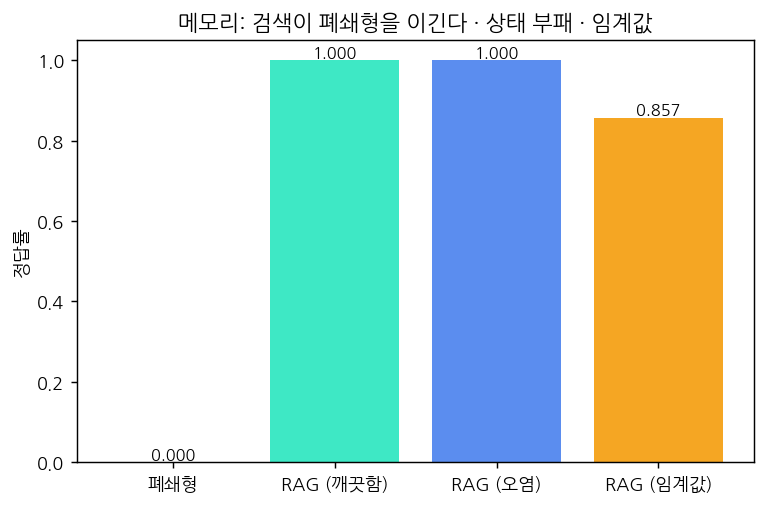

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/04_rag.png
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/04_memory.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (memory-rag: report-only, ~6097 tokens)


{'run_id': '2026-08-19T06:22:41Z',
 'pattern': 'memory-rag',
 'duration_s': 0.0,
 'items_found': 14,
 'actions_taken': 14,
 'escalations': 0,
 'tokens_estimate': 6097,
 'outcome': 'report-only'}

In [6]:
# ── 네 조건을 한 그림에, 그리고 결과 저장 ─────────────────────────
d = show.compare("검색 증강 vs 폐쇄형", cb_acc, rag_acc)

# 막대 네 개를 한 축에 두는 것이 중요하다. 오염과 임계값 조건이 깨끗한 조건과
# 같은 높이에 붙어 있다는 사실 자체가 '포화해서 잴 것이 없었다' 는 증거다.
plotting.ab_bar("04_rag",
                ["폐쇄형", "RAG (깨끗함)", "RAG (오염)", "RAG (임계값)"],
                [cb_acc, rag_acc, rot_acc, thr_acc],
                "정답률",
                "메모리: 검색이 폐쇄형을 이긴다 · 상태 부패 · 임계값")

runlog.save_metrics("04_memory", {
    "notebook": "04_memory",
    "provider": llm.provider,        # 한국어판 추가: 어느 백엔드의 수치인지 기록
    "model": llm.model,
    "embed_backend": mem.backend,    # 한국어판 추가: 검색 실험이므로 임베딩도 기록한다
    "embed_model": mem.model_name,
    "n": n,
    "closed_book": cb_acc,
    "rag": rag_acc,
    "rag_rotted": rot_acc,
    "rag_thresholded": thr_acc,
    "delta": d,
})
runlog.log_run(pattern="memory-rag", duration_s=0, items_found=n, actions_taken=rag_ok,
               escalations=0, tokens_estimate=llm.usage.total_tokens, outcome="report-only")

## 이 실행이 실제로 보여 준 것


In [7]:
# ── 위 수치에서 그대로 계산해 진술한다 (사람이 옮겨 적지 않는다) ──
show.head("이 실행이 실제로 보여 준 것")
print(f"이 프로젝트 고유 사실에 대한 폐쇄형 정답률: {cb_acc:.0%} (모델이 알 수 있는 종류가 아니다).")
print(f"문서 메모리에서 검색했을 때: {rag_acc:.0%} ({d['delta']:+.1%}).")

# 분기해 두는 이유: 상태 부패 실험은 저장소 구성에 따라 손상이 날 수도, 안 날 수도
# 있다. 어느 쪽이 나와도 실행 결과 그대로를 진술하도록 두 문안을 다 준비해 둔다.
if rot_acc < rag_acc - 1e-9:
    print(f"낡은 항목을 넣자(상태 부패) 정답률이 {rot_acc:.0%} 로 떨어졌고, 관련성 임계값이 {thr_acc:.0%} 로 회복시켰다.")
else:
    print(f"낡은 항목을 넣어도 여기서는 정답률이 떨어지지 않았다({rot_acc:.0%}). k=3 에서 진짜 문단이 낡은")
    print("  항목들보다 여전히 높은 순위였다. 상태 부패는 낡은 항목이 진실을 밀어내거나 밀어낼 만큼")
    print("  많아질 때 문다. 진짜 대응은 매 실행마다 해결·만료 항목을 쳐내는 것이고, 관련성 임계값은")
    print("  저품질 잡음에 대한 2선이다.")
print()
print("=> 메모리는 모델 바깥에 사는 지속되는 지식이다. 매 실행마다 옳은 문단을 검색해 오면")
print("   추측이 정답으로 바뀐다. 저장소를 쳐내고 관련성으로 걸러 두면 낡은 상태가 루프를")
print("   오염시키지 못한다. 이것이 상태/메모리 원시 개념의 실물이다.")



========================================= 이 실행이 실제로 보여 준 것 =========================================
이 프로젝트 고유 사실에 대한 폐쇄형 정답률: 0% (모델이 알 수 있는 종류가 아니다).
문서 메모리에서 검색했을 때: 100% (+100.0%).
낡은 항목을 넣어도 여기서는 정답률이 떨어지지 않았다(100%). k=3 에서 진짜 문단이 낡은
  항목들보다 여전히 높은 순위였다. 상태 부패는 낡은 항목이 진실을 밀어내거나 밀어낼 만큼
  많아질 때 문다. 진짜 대응은 매 실행마다 해결·만료 항목을 쳐내는 것이고, 관련성 임계값은
  저품질 잡음에 대한 2선이다.

=> 메모리는 모델 바깥에 사는 지속되는 지식이다. 매 실행마다 옳은 문단을 검색해 오면
   추측이 정답으로 바뀐다. 저장소를 쳐내고 관련성으로 걸러 두면 낡은 상태가 루프를
   오염시키지 못한다. 이것이 상태/메모리 원시 개념의 실물이다.
